📊 Generando análisis visual de volatilidad para GUSH...


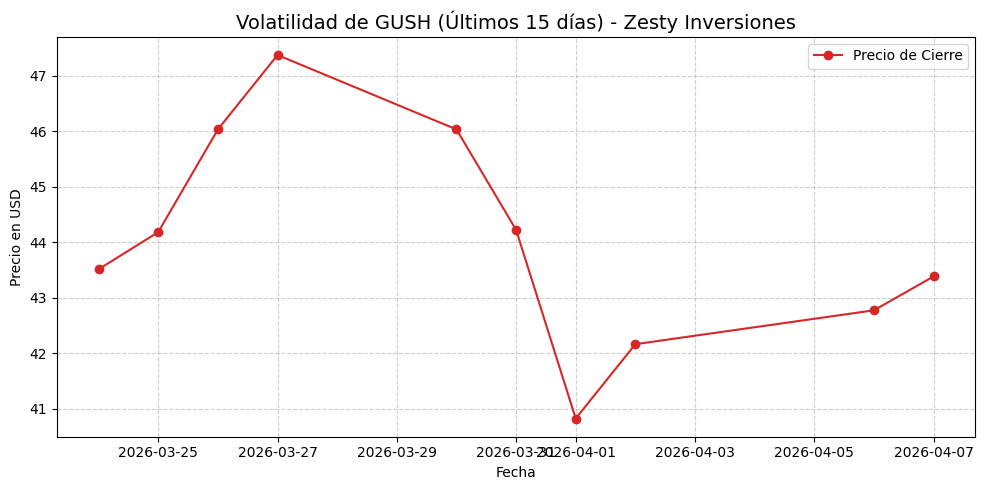


🤖 [SISTEMA INICIADO] Agente Zesty monitoreando GUSH...
📈 Precio de Entrada fijado: $36.65
🛡️ Parámetros: SL -6.0% | TP +10.0%
[2026-04-08 11:12:49] GUSH | Mercado: $38.10 | PnL: 3.96%
[2026-04-08 11:13:19] GUSH | Mercado: $38.10 | PnL: 3.96%
[2026-04-08 11:13:49] GUSH | Mercado: $38.10 | PnL: 3.96%
[2026-04-08 11:14:20] GUSH | Mercado: $38.10 | PnL: 3.96%
[2026-04-08 11:14:50] GUSH | Mercado: $38.11 | PnL: 3.98%
[2026-04-08 11:15:20] GUSH | Mercado: $38.11 | PnL: 3.98%


KeyboardInterrupt: 

In [ ]:
#codigo N°1 con accion de gush de los ultimos 15 dias

import yfinance as yf
import matplotlib.pyplot as plt
import time
import requests
from datetime import datetime, timedelta
import warnings

# Ignorar advertencias menores de la librería matplotlib
warnings.filterwarnings('ignore')

# ==============================================================================
# ⚙️ PARÁMETROS DE CONFIGURACIÓN DEL AGENTE CUANTITATIVO (PERFIL: ALTO RIESGO)
# ==============================================================================
TICKER = "GUSH"              # Direxion Daily S&P Oil & Gas Exp. & Prod. Bull 2X
PRECIO_ENTRADA = 36.65       # ⚠️ REEMPLAZA ESTO: Tu precio exacto de compra en Zesty

# Bandas de tolerancia ajustadas para un ETF Apalancado x2 (Beta Slippage)
STOP_LOSS_PCT = -6.0         # Stop Loss ampliado (-6%) para evitar salidas por ruido
TAKE_PROFIT_PCT = 10.0       # Take Profit asimétrico positivo (10%)

# Credenciales de la API de Telegram
TELEGRAM_TOKEN = "8704161637:AAH8qkIX3W5naDh-8NFSj30X9Hl0tq8RoaE"    # ⚠️ REEMPLAZA CON TU TOKEN DE BOTFATHER
CHAT_ID = "7635175403"         # ⚠️ REEMPLAZA CON TU ID DE CHAT
# ==============================================================================

def graficar_tendencia_zesty(ticker, dias=15):
    """
    Descarga y grafica la tendencia histórica reciente del activo.
    Herramienta de validación visual pre-ejecución.
    """
    print(f"📊 Generando análisis visual de volatilidad para {ticker}...")
    fecha_fin = datetime.now()
    fecha_inicio = fecha_fin - timedelta(days=dias)
    
    datos = yf.download(ticker, start=fecha_inicio.strftime('%Y-%m-%d'), end=fecha_fin.strftime('%Y-%m-%d'), progress=False)
    
    if datos.empty:
        print("⚠️ No se encontraron datos para graficar. Verifica el símbolo.")
        return
        
    plt.figure(figsize=(10, 5))
    plt.plot(datos.index, datos['Close'], marker='o', linestyle='-', color='#d62728', label='Precio de Cierre')
    plt.title(f"Volatilidad de {ticker} (Últimos {dias} días) - Zesty Inversiones", fontsize=14)
    plt.xlabel("Fecha")
    plt.ylabel("Precio en USD")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

def enviar_mensaje_telegram(mensaje):
    """
    Wrapper para la API de Telegram. Envía alertas estructuradas.
    """
    url = f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendMessage"
    payload = {"chat_id": CHAT_ID, "text": mensaje, "parse_mode": "Markdown"}
    try:
        respuesta = requests.post(url, json=payload)
        if respuesta.status_code != 200:
            print(f"⚠️ Error de Telegram: {respuesta.text}")
    except Exception as e:
        print(f"⚠️ Excepción de red al contactar Telegram: {e}")

def agente_zesty_operativo():
    """
    Bucle principal del algoritmo de monitoreo de alta frecuencia (1m).
    """
    print(f"\n🤖 [SISTEMA INICIADO] Agente Zesty monitoreando {TICKER}...")
    print(f"📈 Precio de Entrada fijado: ${PRECIO_ENTRADA:.2f}")
    print(f"🛡️ Parámetros: SL {STOP_LOSS_PCT}% | TP +{TAKE_PROFIT_PCT}%")
    
    mensaje_inicio = (
        f"🟢 *Agente Zesty Iniciado*\n"
        f"Activo: `{TICKER}` (Apalancado 2x)\n"
        f"Precio Entrada Base: ${PRECIO_ENTRADA:.2f}\n"
        f"Estrategia: SL {STOP_LOSS_PCT}% | TP +{TAKE_PROFIT_PCT}%"
    )
    enviar_mensaje_telegram(mensaje_inicio)
    
    intentos_fallidos = 0
    
    while True:
        try:
            hora_actual = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            
            # Petición a la API de Yahoo Finance (datos de hoy, intervalos de 1 minuto)
            activo = yf.Ticker(TICKER)
            datos_hoy = activo.history(period="1d", interval="1m")
            
            if datos_hoy.empty:
                print(f"[{hora_actual}] 💤 Mercado cerrado o sin liquidez momentánea para {TICKER}.")
                time.sleep(300) # Espera 5 minutos
                continue
                
            # Extracción del último precio cruzado en el mercado
            precio_actual = float(datos_hoy['Close'].iloc[-1])
            
            # Cálculo de rendimiento continuo (Retorno aritmético simple)
            variacion_pct = ((precio_actual - PRECIO_ENTRADA) / PRECIO_ENTRADA) * 100
            
            print(f"[{hora_actual}] {TICKER} | Mercado: ${precio_actual:.2f} | PnL: {variacion_pct:.2f}%")
            
            # --- MOTOR DE DECISIÓN (ALGORITMO DE SALIDA) ---
            if variacion_pct <= STOP_LOSS_PCT:
                alerta = (
                    f"🚨 *STOP LOSS TÁCTICO ALCANZADO*\n"
                    f"Activo: `{TICKER}`\n"
                    f"Precio Mercado: ${precio_actual:.2f}\n"
                    f"Caída PnL: {variacion_pct:.2f}%\n"
                    f"Acción: El algoritmo sugiere liquidar posición para mitigar arrastre de volatilidad."
                )
                enviar_mensaje_telegram(alerta)
                print("🛑 Condición de Stop Loss cumplida. Agente finalizado.")
                break 
                
            elif variacion_pct >= TAKE_PROFIT_PCT:
                alerta = (
                    f"🎯 *TAKE PROFIT ALCANZADO*\n"
                    f"Activo: `{TICKER}`\n"
                    f"Precio Mercado: ${precio_actual:.2f}\n"
                    f"Rendimiento PnL: +{variacion_pct:.2f}%\n"
                    f"Acción: El algoritmo sugiere toma de ganancias."
                )
                enviar_mensaje_telegram(alerta)
                print("✅ Condición de Take Profit cumplida. Agente finalizado.")
                break 
            
            # Reset de estado de red
            intentos_fallidos = 0
            
            # Frecuencia de muestreo: 5 minutos (300 segundos)
            time.sleep(30)
            
        except Exception as e:
            intentos_fallidos += 1
            print(f"⚠️ Error de lectura de datos (Intento {intentos_fallidos}/5): {e}")
            if intentos_fallidos >= 5:
                enviar_mensaje_telegram("⚠️ *Alerta de Infraestructura*\nPérdida prolongada de conexión con el proveedor de datos (YF). El agente se ha detenido.")
                break
            time.sleep(60) # Espera 1 minuto ante caída de red antes del próximo request

# ==============================================================================
# 🚀 EJECUCIÓN SECUENCIAL
# ==============================================================================
if __name__ == "__main__":
    # 1. Ejecutamos la gráfica para validación
    graficar_tendencia_zesty(TICKER, dias=15)
    
    # 2. Iniciamos el bucle infinito del bot (La terminal se quedará bloqueada aquí)
    agente_zesty_operativo()

In [ ]:
#codigo N°1.1 Verificar si la accion comenzó el día.

import yfinance as yf
import matplotlib.pyplot as plt
import time
import requests
from datetime import datetime, timedelta
import warnings
import yfinance as yf
from datetime import datetime
import pytz

def check_market_status(ticker_symbol):
    """
    Evalúa si el mercado para un ticker específico está abierto
    utilizando metadatos de la API de Yahoo Finance.
    """
    try:
        # Instanciar el objeto ticker
        asset = yf.Ticker(ticker_symbol)
        
        # Obtener información rápida de mercado
        # Fast info provee acceso a precios y estados de mercado en tiempo real
        info = asset.fast_info
        
        # Extraer el precio actual y el estado
        current_price = info['last_price']
        exchange = info['exchange']
        
        # Determinar si está en sesión de mercado regular
        # Nota: yfinance a veces devuelve el estado en info['market_state']
        # Pero una validación robusta cruza la hora actual con el huso horario del exchange (EST/EDT)
        
        market_state = asset.info.get('marketState', 'UNKNOWN')
        
        print(f"--- Análisis de Estado: {ticker_symbol} ---")
        print(f"Exchange: {exchange}")
        print(f"Último precio capturado: US$ {current_price:.2f}")
        print(f"Estado del Mercado: {market_state}")
        
        if market_state == 'REGULAR':
            print("🟢 La sesión de mercado está ABIERTA. Ejecución operativa recomendada.")
        elif market_state in ['PRE', 'POST', 'CLOSED']:
            print(f"🔴 El mercado está en fase {market_state}. Precaución: Liquidez reducida.")
        else:
            print("⚠️ No se pudo determinar el estado exacto. Verifique conectividad con la API.")

    except Exception as e:
        print(f"Error en la extracción de datos cuantitativos: {e}")

# Ejecución para GUSH
check_market_status("GUSH")

: 

In [1]:
#codigo N°2 con accion de gush del ultimo dia

import yfinance as yf
import matplotlib.pyplot as plt
import time
import requests
from datetime import datetime, timedelta
import warnings

# Ignorar advertencias menores de la librería matplotlib
warnings.filterwarnings('ignore')

# ==============================================================================
# ⚙️ PARÁMETROS DE CONFIGURACIÓN DEL AGENTE CUANTITATIVO (PERFIL: ALTO RIESGO)
# ==============================================================================
TICKER = "GUSH"              # Direxion Daily S&P Oil & Gas Exp. & Prod. Bull 2X
PRECIO_ENTRADA = 39.48       # Precio exacto de compra en Zesty 09/04/2026

# Bandas de tolerancia ajustadas para un ETF Apalancado x2 (Beta Slippage)
STOP_LOSS_PCT = -6.0         # Stop Loss ampliado (-6%) para evitar salidas por ruido
TAKE_PROFIT_PCT = 10.0       # Take Profit asimétrico positivo (10%)

# Credenciales de la API de Telegram (CORREGIDAS)
TELEGRAM_TOKEN = "8704161637:AAH8qkIX3W5naDh-8NFSj30X9Hl0tq8RoaE"    
CHAT_ID = "7635175403"       # ⚠️ Sin el símbolo @ para IDs numéricos privados
# ==============================================================================

def graficar_tendencia_zesty(ticker, dias=1):
    """
    Descarga y grafica la tendencia histórica reciente del activo.
    Herramienta de validación visual pre-ejecución.
    """
    print(f"📊 Generando análisis visual de volatilidad para {ticker}...")
    fecha_fin = datetime.now()
    fecha_inicio = fecha_fin - timedelta(days=dias)
    
    datos = yf.download(ticker, start=fecha_inicio.strftime('%Y-%m-%d'), end=fecha_fin.strftime('%Y-%m-%d'), progress=False)
    
    if datos.empty:
        print("⚠️ No se encontraron datos para graficar. Verifica el símbolo.")
        return
        
    plt.figure(figsize=(10, 5))
    plt.plot(datos.index, datos['Close'], marker='o', linestyle='-', color='#d62728', label='Precio de Cierre')
    plt.title(f"Volatilidad de {ticker} (Últimos {dias} días) - Zesty Inversiones", fontsize=14)
    plt.xlabel("Fecha")
    plt.ylabel("Precio en USD")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

def enviar_mensaje_telegram(mensaje):
    """
    Wrapper para la API de Telegram. Envía alertas estructuradas.
    """
    url = f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendMessage"
    payload = {"chat_id": CHAT_ID, "text": mensaje, "parse_mode": "Markdown"}
    try:
        respuesta = requests.post(url, json=payload)
        if respuesta.status_code != 200:
            print(f"⚠️ Error de Telegram: {respuesta.text}")
    except Exception as e:
        print(f"⚠️ Excepción de red al contactar Telegram: {e}")

def agente_zesty_operativo():
    """
    Bucle principal del algoritmo de monitoreo de alta frecuencia con Gráfico en Tiempo Real.
    """
    print(f"\n🤖 [SISTEMA INICIADO] Agente Zesty monitoreando {TICKER}...")
    
    mensaje_inicio = (
        f"🟢 *Agente Zesty Iniciado (Modo Visual)*\n"
        f"Activo: `{TICKER}`\n"
        f"Precio Entrada Base: ${PRECIO_ENTRADA:.2f}\n"
        f"Estrategia: SL {STOP_LOSS_PCT}% | TP +{TAKE_PROFIT_PCT}%"
    )
    enviar_mensaje_telegram(mensaje_inicio)
    
    intentos_fallidos = 0
    
    # 1. INICIALIZACIÓN DEL ENTORNO GRÁFICO INTERACTIVO
    plt.ion() # Activa el modo interactivo
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Calculamos los precios exactos de salida para graficarlos
    precio_sl = PRECIO_ENTRADA * (1 + (STOP_LOSS_PCT / 100))
    precio_tp = PRECIO_ENTRADA * (1 + (TAKE_PROFIT_PCT / 100))
    
    while True:
        try:
            hora_actual = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            
            # Petición a la API de Yahoo Finance (datos de HOY, intervalos de 1 minuto)
            activo = yf.Ticker(TICKER)
            datos_hoy = activo.history(period="1d", interval="1m")
            
            if datos_hoy.empty:
                print(f"[{hora_actual}] 💤 Mercado cerrado o sin liquidez momentánea para {TICKER}.")
                plt.pause(300) # Pausa interactiva de 5 min si el mercado está cerrado
                continue
                
            # Extracción del último precio cruzado
            precio_actual = float(datos_hoy['Close'].iloc[-1])
            variacion_pct = ((precio_actual - PRECIO_ENTRADA) / PRECIO_ENTRADA) * 100
            
            print(f"[{hora_actual}] {TICKER} | Mercado: ${precio_actual:.2f} | PnL: {variacion_pct:.2f}%")
            
            # 2. ACTUALIZACIÓN DEL GRÁFICO EN TIEMPO REAL
            ax.clear() # Limpiamos el gráfico anterior
            
            # Graficamos la serie de tiempo de hoy
            ax.plot(datos_hoy.index, datos_hoy['Close'], color='black', linewidth=1.5, label=f'{TICKER} (Intradía)')
            
            # Graficamos las bandas de tolerancia de Zesty
            ax.axhline(y=PRECIO_ENTRADA, color='blue', linestyle='-', alpha=0.5, label=f'Entrada (${PRECIO_ENTRADA})')
            ax.axhline(y=precio_tp, color='green', linestyle='--', linewidth=2, label=f'Take Profit (+{TAKE_PROFIT_PCT}%)')
            ax.axhline(y=precio_sl, color='red', linestyle='--', linewidth=2, label=f'Stop Loss ({STOP_LOSS_PCT}%)')
            
            # Formateo visual
            ax.set_title(f"Monitor Zesty en Tiempo Real: {TICKER} | Actual: ${precio_actual:.2f}", fontsize=12, fontweight='bold')
            ax.set_ylabel("Precio (USD)")
            ax.grid(True, linestyle=':', alpha=0.7)
            ax.legend(loc='upper left')
            
            # Forzamos la actualización visual de la ventana
            fig.canvas.draw()
            fig.canvas.flush_events()
            
            # --- MOTOR DE DECISIÓN (ALGORITMO DE SALIDA) ---
            if variacion_pct <= STOP_LOSS_PCT:
                enviar_mensaje_telegram(f"🚨 *STOP LOSS TÁCTICO ALCANZADO*\nActivo: `{TICKER}`\nPrecio: ${precio_actual:.2f}\nCaída: {variacion_pct:.2f}%")
                print("🛑 Stop Loss cumplido. Agente finalizado.")
                plt.ioff() # Desactiva modo interactivo
                plt.show() # Mantiene el gráfico final abierto
                break 
                
            elif variacion_pct >= TAKE_PROFIT_PCT:
                enviar_mensaje_telegram(f"🎯 *TAKE PROFIT ALCANZADO*\nActivo: `{TICKER}`\nPrecio: ${precio_actual:.2f}\nGanancia: +{variacion_pct:.2f}%")
                print("✅ Take Profit cumplido. Agente finalizado.")
                plt.ioff()
                plt.show()
                break 
            
            intentos_fallidos = 0
            
            # 3. EL NUEVO "SLEEP" QUE MANTIENE VIVO EL GRÁFICO
            # Pausamos 30 segundos, pero permitiendo que el gráfico se mantenga responsivo
            plt.pause(30)
            
        except Exception as e:
            intentos_fallidos += 1
            print(f"⚠️ Error de lectura de datos (Intento {intentos_fallidos}/5): {e}")
            if intentos_fallidos >= 5:
                enviar_mensaje_telegram("⚠️ *Alerta de Infraestructura*\nPérdida prolongada de conexión (YF).")
                break
            plt.pause(60)

# ==============================================================================
# 🚀 EJECUCIÓN SECUENCIAL
# ==============================================================================
if __name__ == "__main__":
    # Eliminamos la gráfica estática previa y lanzamos directamente el bot visual
    agente_zesty_operativo()

ModuleNotFoundError: No module named 'yfinance'